In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout


In [2]:
import sys
import os

In [3]:
# Add current notebook folder to Python path
sys.path.append(os.getcwd())

In [4]:
## import my data_preprocessing.py file
from preprocessing import load_data, clean_data, describe_data, plot_prices

In [5]:
data = load_data("E:/7th semester/Deep Learning/labs/DL-Assigment/data/BAJAJ-AUTO.csv")
data.head(100)


,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2008-05-26,BAJAJ-AUTO,EQ,2101.05,898.00,898.00,551.35,600.25,604.75,624.61,3972485,2.481245e+14,NaN,1202933,0.3028
1,2008-05-27,BAJAJ-AUTO,EQ,604.75,624.70,639.00,580.30,595.50,593.15,606.43,1751063,1.061901e+14,NaN,369389,0.2110
2,2008-05-28,BAJAJ-AUTO,EQ,593.15,561.65,621.90,561.65,605.10,608.15,608.75,1652355,1.005877e+14,NaN,898602,0.5438
3,2008-05-29,BAJAJ-AUTO,EQ,608.15,619.40,619.40,576.00,600.00,599.45,600.98,669269,4.022165e+13,NaN,449951,0.6723
4,2008-05-30,BAJAJ-AUTO,EQ,599.45,605.40,607.00,538.00,576.25,571.70,565.55,1262117,7.137937e+13,NaN,936432,0.7420
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,2008-10-10,BAJAJ-AUTO,EQ,544.15,501.10,524.90,425.00,425.00,462.65,500.20,208322,1.042023e+13,NaN,179589,0.8621
96,2008-10-13,BAJAJ-AUTO,EQ,462.65,457.00,527.90,450.00,511.00,514.50,500.36,153103,7.660593e+12,NaN,124001,0.8099
97,2008-10-14,BAJAJ-AUTO,EQ,514.50,527.00,590.65,525.00,534.00,540.60,557.36,183201,1.021090e+13,NaN,153074,0.8356
98,2008-10-15,BAJAJ-AUTO,EQ,540.60,523.05,545.00,459.50,544.00,529.20,498.19,156439,7.793700e+12,NaN,130055,0.8313


In [6]:
data.shape

(3202, 15)

In [7]:
# getting the should be predict value
Close = data.iloc[:, 8]  
print(Close[:10])   


0    604.75
1    593.15
2    608.15
3    599.45
4    571.70
5    580.80
6    579.70
7    552.10
8    562.40
9    568.80
Name: Close, dtype: float64


In [8]:
## getting Close price variation

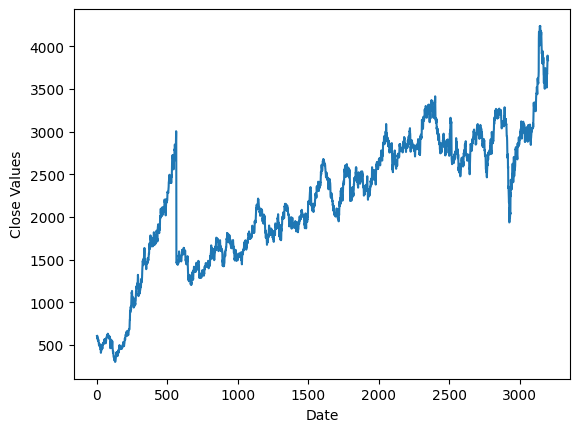

In [9]:
import matplotlib.pyplot as plt
plt.plot(Close)
plt.xlabel("Date")
plt.ylabel("Close Values")
plt.show()

Data Description:
        Prev Close         Open         High          Low         Last  \
count  3202.000000  3202.000000  3202.000000  3202.000000  3202.000000   
mean   2189.871065  2191.537883  2219.934510  2162.215209  2190.307917   
std     774.552766   776.148452   781.289529   770.192017   775.065896   
min     301.900000   262.000000   307.050000   262.000000   300.000000   
25%    1661.925000  1663.250000  1693.775000  1636.362500  1660.512500   
50%    2269.950000  2270.000000  2305.575000  2240.250000  2270.750000   
75%    2808.437500  2810.000000  2834.950000  2778.362500  2808.975000   
max    4237.450000  4260.000000  4361.400000  4200.000000  4236.000000   

             Close         VWAP  
count  3202.000000  3202.000000  
mean   2190.412196  2191.294288  
std     775.095766   775.657353  
min     301.900000   301.980000  
25%    1661.925000  1664.845000  
50%    2270.225000  2269.900000  
75%    2808.487500  2808.565000  
max    4237.450000  4260.500000  

Number o

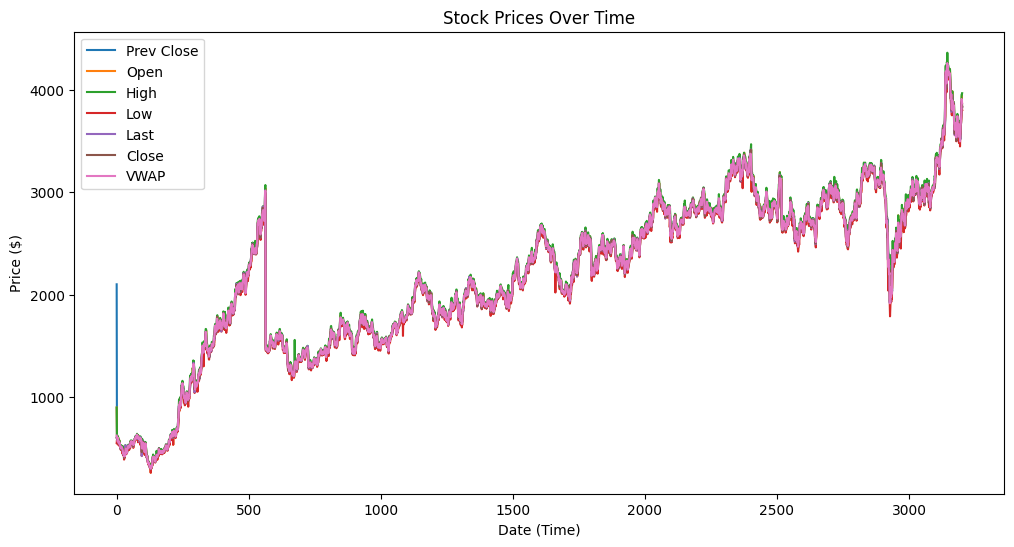

In [10]:
cleaned_data = clean_data(data)
describe_data(cleaned_data)
plot_prices(cleaned_data)

In [11]:
## scale the close data
Close = Close.values.reshape(-1,1) 
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))
scaled_Close = scaler.fit_transform(Close)


In [12]:
## scale sample first 50 data values between 0-1
print(Close[:50].T)
print(scaled_Close[:50].T)

[[604.75 593.15 608.15 599.45 571.7  580.8  579.7  552.1  562.4  568.8
  548.8  550.4  530.5  519.45 505.9  494.65 506.7  516.45 512.55 512.1
  502.3  479.   497.3  488.95 453.95 450.35 447.1  453.5  408.6  421.
  435.5  434.5  451.75 498.45 499.95 501.65 479.85 455.   467.6  464.1
  498.9  495.05 519.   520.65 509.95 515.55 509.4  519.75 533.7  517.65]]
[[0.0769524  0.0740049  0.07781632 0.0756057  0.06855459 0.07086684
  0.07058734 0.06357434 0.06619151 0.06781771 0.06273583 0.06314238
  0.05808591 0.05527817 0.05183519 0.04897664 0.05203847 0.05451589
  0.05352492 0.05341058 0.05092046 0.04500006 0.04964999 0.0475283
  0.03863501 0.03772027 0.03689446 0.03852066 0.02711184 0.03026261
  0.03394697 0.03369288 0.038076   0.04994219 0.05032333 0.05075529
  0.04521604 0.03890181 0.04210339 0.04121406 0.05005654 0.04907827
  0.05516383 0.05558308 0.05286428 0.0542872  0.05272452 0.0553544
  0.05889901 0.0548208 ]]


In [13]:
## create window size 

data1 = []
target = []

window_size = 50
for i in range(0,len(Close)-window_size):
    data1.append(scaled_Close[i:i+window_size])
    target.append(scaled_Close[i+window_size])

In [14]:
import numpy as np

data_np = np.array(data1)
target_np = np.array(target)

print(data_np.shape)
print(target_np.shape)

(3152, 50, 1)
(3152, 1)


In [15]:
## save data and target after splitting windows

np.save('data1',data)
np.save('target',target)

In [16]:
## train and test data 

In [17]:
train_data = data1[:2500]
train_target = target[:2500]

test_data = data1[2500:]
test_target = target[2500:]


In [18]:

train_data = np.array(train_data)
test_data = np.array(test_data)
train_target = np.array(train_target)
test_target = np.array(test_target)

print(train_data.shape)
print(test_data.shape)
print(train_target.shape)
print(test_target.shape)


(2500, 50, 1)
(652, 50, 1)
(2500, 1)
(652, 1)


In [19]:
## train target and test target value visualization

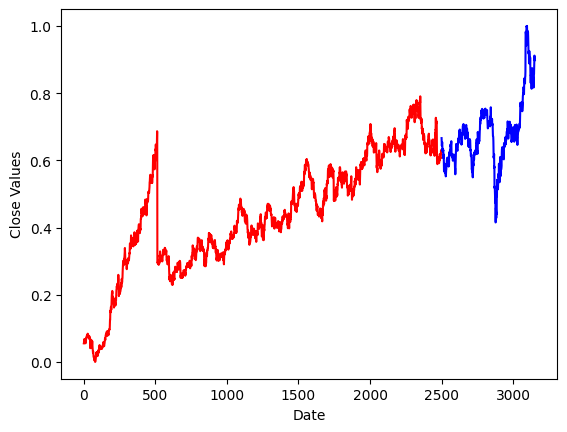

In [20]:
test_x_range = np.arange(2500,3152,1)
plt.plot(train_target,'r',label='train')
plt.plot(test_x_range,test_target,'b',label='test')
plt.xlabel("Date")
plt.ylabel("Close Values")
plt.show()

In [21]:
## Lstm model creation

from keras.models import Sequential
from keras.layers import LSTM,Dense,Dropout

model=Sequential()

model.add(LSTM(units=96,return_sequences=True,input_shape=(50,1)))
model.add(Dropout(0.2))

model.add(LSTM(units=96,return_sequences=True))
model.add(Dropout(0.2))

model.add(LSTM(units=96,return_sequences=True))
model.add(Dropout(0.2))

model.add(LSTM(units=40,return_sequences=False))
model.add(Dropout(0.2))

model.add(Dense(1,activation='linear'))

model.compile(loss='mse',optimizer='adam')

C:\Users\USER\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [26]:
history=model.fit(train_data,train_target,epochs=50,validation_data=(test_data,test_target))

Epoch 1/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - loss: 6.4052e-04 - val_loss: 3.8118e-04
Epoch 2/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 112ms/step - loss: 6.0607e-04 - val_loss: 2.8652e-04
Epoch 3/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 90ms/step - loss: 7.0890e-04 - val_loss: 3.1691e-04
Epoch 4/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 72ms/step - loss: 6.0557e-04 - val_loss: 2.7020e-04
Epoch 5/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 101ms/step - loss: 5.6383e-04 - val_loss: 2.8291e-04
Epoch 6/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 97ms/step - loss: 5.7517e-04 - val_loss: 3.8076e-04
Epoch 7/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 111ms/step - loss: 5.9031e-04 - val_loss: 2.6072e-04
Epoch 8/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 23s 279ms/step - loss: 5.7722e-04 - val_loss: 2.6213e-04
Epoch 9/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - loss: 5.7294e-04 - val_loss: 4.3520e-04
Epoch 10/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 88ms/step - loss: 5.7854e-04 - val_loss: 6.3494e-04
Epoch 11/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 79ms/step - loss: 5.41

In [23]:
## visualize the train loass and val_loass

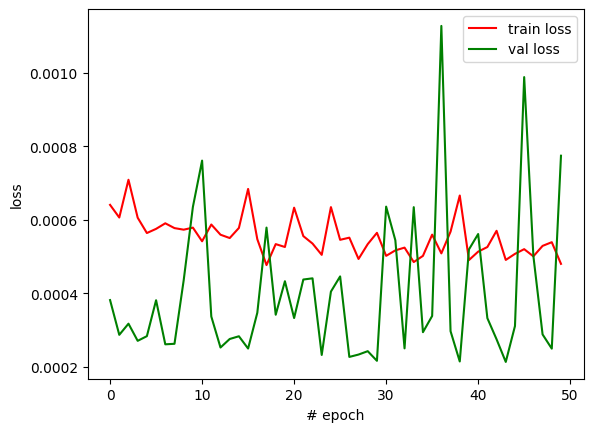

In [27]:
plt.plot(history.history['loss'],'r',label='train loss')
plt.plot(history.history['val_loss'],'g',label='val loss')
plt.xlabel('# epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

In [28]:
## predict the accuracy of model

In [29]:
result=model.predict(test_data)

from sklearn.metrics import r2_score

r2=r2_score(test_target,result)
print('r2 score:',r2)

21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step
r2 score: 0.9236721480035398


In [30]:
## final visualization of between changes of actual and predicted values


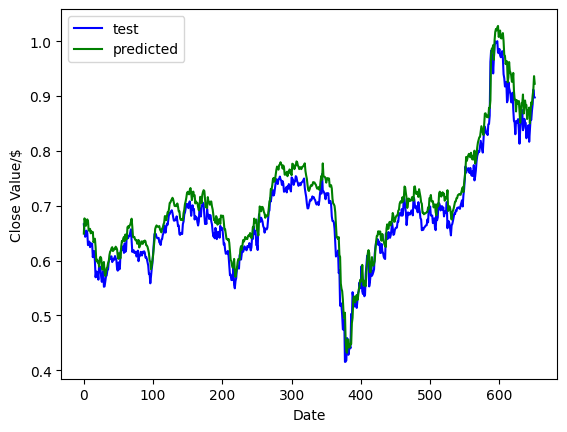

In [31]:
plt.plot(test_target,'b',label='test')
plt.plot(result,'g',label='predicted')

plt.xlabel('Date')
plt.ylabel('Close Value/$')
plt.legend()
plt.show()